In [8]:
%reload_ext autoreload
%autoreload 2
import pandeia.engine
import stsynphot
import synphot
from synphot import SpectralElement
from synphot.models import Empirical1D
import os, glob, sys
import numpy as np
from astropy.io import fits
import astropy.units as u
import astropy.constants as const
from scipy import interpolate
from scipy.integrate import simpson
import matplotlib.pyplot as plt
from rsg import rsg_phot
from tqdm import tqdm
%matplotlib inline

In [9]:
syn_rsg = rsg_phot()
rsgspec = syn_rsg.create_rsg(1, 2, 3500, 1000)
filts = ['f070w', 'f090w', 'f115w', 'f150w', 'f182m', 'f200w', 'f210m', 'f277w', 'f335m', 'f356w', 'f444w']
rsgmag = syn_rsg.compute_rsg_mag(filts, 1, 2, 3500, 1000)

In [10]:
filts = ['f070w', 'f090w', 'f115w', 'f150w', 'f182m', 'f200w', 'f210m', 'f277w', 'f335m', 'f356w', 'f444w']
syn_rsg = rsg_phot()
rsg_temps = np.linspace(3000, 5000, 11)
taus = np.linspace(0.01, 5, 11)

f115w_mag, f200w_mag = [], []

for i,temp in tqdm(enumerate(rsg_temps)):
    for j,tau in enumerate(taus):
        try:
            rsgmag = syn_rsg.compute_rsg_mag(filts, tau, 2, temp, 1000)
            f115w_mag.append(rsgmag['f115w'].value)
            f200w_mag.append(rsgmag['f200w'].value)
        except:
            f115w_mag.append(np.nan)
            f200w_mag.append(np.nan)

f115w_mag, f200w_mag = np.array(f115w_mag), np.array(f200w_mag)

11it [00:42,  3.87s/it]


Text(0, 0.5, 'Flux (PHOTLAM)')

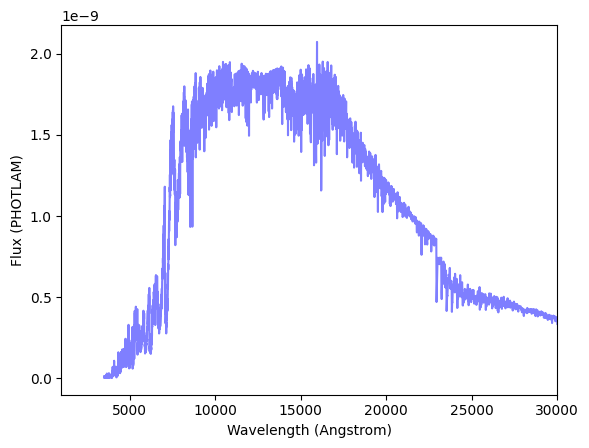

In [11]:
wvs = rsgspec.waveset
plt.plot(wvs, rsgspec(wvs), color = 'blue', alpha = 0.5)
plt.xlim(1000, 30000)
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux (PHOTLAM)')

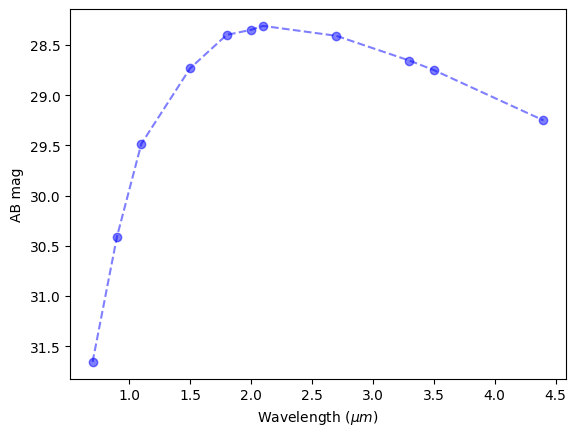

In [12]:
wvs = [float(i[1:3])/10 for i in filts]
mags = [rsgmag[flt].value for flt in filts]
plt.plot(wvs, mags, color = 'blue', alpha = 0.5, marker = 'o', linestyle = '--')
plt.xlabel(r'Wavelength (${\mu}m$)')
plt.ylabel('AB mag')
plt.gca().invert_yaxis()

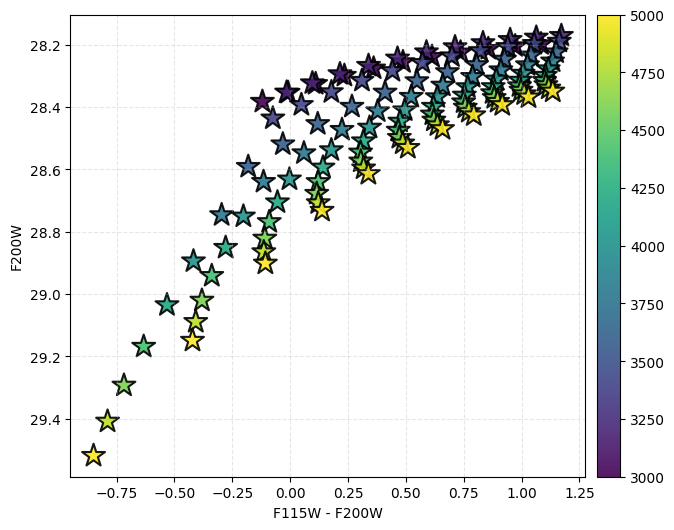

In [13]:
flt_1, flt_2 = 'f115w', 'f200w'
plt.figure(figsize = (8, 6))
plt.scatter(f115w_mag-f200w_mag, f200w_mag, marker='*', s=300, c=np.repeat(rsg_temps, 11),
            cmap='viridis', edgecolors='black', lw=1.5, alpha=0.9)
plt.colorbar(pad = 0.02)
plt.xlabel(f'{flt_1.upper()} - {flt_2.upper()}')
plt.ylabel(f'{flt_2.upper()}')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, linestyle='--')